In [1]:
import numpy as np
import pandas as pd
from scipy import stats

In [2]:
def cohens(x, y):
    r"""Effect size metric through Cohen's *d* metric
    :param x: first vector
    :param y: second vector
    :return: absolute effect size value
    The Cohen's effect size *d* is defined as the difference
    between two means divided by a standard deviation of the data.
    .. math::
        d = \frac{\bar{x}_1 - \bar{x}_2}{s}
    For two independent samples, the *pooled standard deviation* is used
    instead, which is defined as:
    .. math::
        s = \sqrt{  \frac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1+n_2-2} }
    A Cohen's *d* is frequently used in estimating sample sizes for
    statistical testing: a lower *d* value indicates the necessity of
    larger sample sizes, and vice versa.
    .. note:: we return the absolute value
    :references: https://en.wikipedia.org/wiki/Effect_size
    """
    x = np.array(x)
    y = np.array(y)

    Nx = len(x) - 1.  # note the dot to cast to float
    Ny = len(y) - 1.
    # mean difference:
    md = np.abs(x.mean() - y.mean())
    # here, we want same as in R that is unbiased variance
    # so we use ddof = 1
    xv = x.var(ddof=1)
    yv = y.var(ddof=1)
    csd = Nx * xv + Ny * yv
    csd /= Nx + Ny  # make sure this is float
    csd = np.sqrt(csd)

    return md / csd

In [3]:
df = pd.read_csv('../data/20240620/normalised_gfp_all_clones.tsv', sep = '\t', index_col = 0)
df = df[df.index >= 400]
df.head(5)

,cadB-ctrl,cadB-test,mhpR-ctrl,mhpR-test,pdeL-ctrl,pdeL-test,waaQ-ctrl,waaQ-test,xapR-ctrl,xapR-test,...,yaeL-ctrl,yaeL-test,yeeD-ctrl,yeeD-test,yfdQ-ctrl,yfdQ-test,yfgJ-ctrl,yfgJ-test,yqiD-ctrl,yqiD-test
Time,,,,,,,,,,,,,,,,,,,,,
420,19285.945073,45041.916168,5914.209115,3137.457045,4477.272727,6182.978723,12015.384615,6134.057971,5232.142857,3704.697987,...,4723.076923,4135.593220,4933.333333,4147.058824,3186.274510,3844.155844,2670.103093,2531.531532,1790.123457,17276.315789
450,23112.033195,44819.354839,6148.387097,3282.913165,4152.439024,5788.395904,11250.000000,6020.710059,4982.758621,3681.198910,...,5415.584416,4600.000000,5146.666667,4050.632911,3380.165289,3923.913043,2210.526316,2223.880597,2010.309278,18205.555556
480,26069.575472,44669.367909,5896.272285,3122.844828,3983.213429,5543.535620,11198.198198,5695.652174,5097.560976,3573.593074,...,5062.500000,4792.682927,5472.527473,3842.105263,3212.328767,3071.428571,2166.666667,2296.296296,1672.413793,18140.271493
510,28071.500504,43626.444159,5523.696682,2897.476341,3413.602941,5150.197628,10192.371476,5272.251309,4698.275862,3503.496503,...,5780.701754,5793.814433,5192.982456,4203.539823,3655.172414,3107.142857,2150.537634,2307.317073,3000.000000,18301.470588
540,29245.315162,42127.771911,5291.311755,2680.572110,3156.918688,4651.094891,9427.148194,4752.355316,4390.243902,3151.988636,...,5137.931034,5114.035088,4833.333333,3342.857143,2925.925926,2775.862069,1563.265306,1778.625954,1719.298246,17730.994152


In [4]:
nc = pd.read_csv('../data/20260731/normalised_gfp_notarget.tsv', sep = '\t', index_col = 0)
nc = nc[nc.index >= 400]
print(f'{nc.shape[1] // 2} genes, {nc.shape[0]} time points ({nc.index.min()}-{nc.index.max()} min)')
nc.head(5)

8 genes, 19 time points (420-960 min)


,amyA-ctrl,amyA-test,dmlR-ctrl,dmlR-test,flhC-ctrl,flhC-test,fliT-ctrl,fliT-test,rclR-ctrl,rclR-test,ybaM-ctrl,ybaM-test,ycjY-ctrl,ycjY-test,ygiL-ctrl,ygiL-test
Time,,,,,,,,,,,,,,,,
420,7129.948518,5181.273000,7312.686436,5112.172252,2507.873390,2465.155176,3023.083265,2749.774001,56172.300082,97447.337278,2723.371516,2668.305013,3093.991484,3151.449876,2343.125111,2505.958511
450,6568.869210,4990.546892,7169.872682,4794.979350,2428.983094,2275.565050,2801.989730,2587.938657,54813.801740,90901.099612,2652.623749,2712.431382,3085.364289,3193.061942,2360.811991,2421.201945
480,6447.919639,5146.869352,7281.838348,4796.089245,2472.801276,2169.064184,2830.383560,2474.425178,55158.411039,88160.520156,2640.920111,2899.005703,3187.406629,3171.991690,2275.127427,2480.760747
510,6815.568443,5361.516643,8157.162795,5508.528785,2670.427268,2386.704556,2994.856064,2837.019848,59850.023798,91845.868196,2713.219000,3102.945020,3213.891794,3395.058635,2497.110125,2736.271996
540,6708.274715,5204.764371,8184.416553,5813.326860,2652.009283,2482.480105,2944.556094,2986.976144,57946.294307,92690.315454,2806.799851,3089.248377,3294.701576,3362.876045,2567.188127,2784.940230


In [5]:
groups = set([c.split('-')[0] for c in df.columns])

results = []

# Loop through each pair of columns to compute the effect size
for gene in groups:
    ctrl_col = f'{gene}-ctrl'
    test_col = f'{gene}-test'
    effect_size = cohens(df[ctrl_col], df[test_col])
    results.append({'Gene_promoter': gene, 'effect_size': effect_size})

# Create a new DataFrame with the results
result_df = pd.DataFrame(results) 
#result_df.to_csv('/Users/bamudamaris/ownCloud2/labs/datasets/cohens.tsv', sep = '\t', index = False)
result_df

,Gene_promoter,effect_size
0,yhaV,6.137830
1,yeeD,1.010678
2,pdeL,1.715919
3,cadB,2.036431
4,waaQ,3.644323
5,mhpR,8.899287
6,yodB,10.012243
7,ghoS,0.942187
8,yadN,1.921453
9,xapR,2.654982


In [6]:
# Define the total count explicitly
count = result_df.shape[0]

# Effect size classifications
small_effect = result_df[result_df['effect_size'] <= 0.2].shape[0]
medium_effect = result_df[(result_df['effect_size'] > 0.2) & (result_df['effect_size'] < 0.8)].shape[0]
large_effect = result_df[result_df['effect_size'] >= 0.8].shape[0]

# Print the results
print(f"Small effect (d ≤ 0.2): {small_effect} ({small_effect/count*100:.2f}%)")
print(f"Medium effect (0.2 < d < 0.8): {medium_effect} ({medium_effect/count*100:.2f}%)")
print(f"Large effect (d ≥ 0.8): {large_effect} ({large_effect/count*100:.2f}%)")


Small effect (d ≤ 0.2): 2 (11.11%)
Medium effect (0.2 < d < 0.8): 4 (22.22%)
Large effect (d ≥ 0.8): 12 (66.67%)


In [7]:
def pair_values(frame, gene):
    """The ctrl and test columns of one gene, on their shared time points."""
    pair = frame[[f'{gene}-ctrl', f'{gene}-test']].dropna()
    return pair[f'{gene}-ctrl'], pair[f'{gene}-test']


nc_groups = sorted(set([c.split('-')[0] for c in nc.columns]))

nc_effect = pd.DataFrame([
    {'Gene_promoter': gene, 'effect_size': cohens(*pair_values(nc, gene))}
    for gene in nc_groups
])
nc_effect.sort_values('effect_size', ascending = False)

,Gene_promoter,effect_size
4,rclR,7.485808
1,dmlR,2.620812
0,amyA,2.170434
3,fliT,2.148483
2,flhC,1.999038
7,ygiL,1.235081
5,ybaM,0.188925
6,ycjY,0.078395


In [8]:
# Same classification as above, applied to the negative controls
nc_count = nc_effect.shape[0]

nc_small = nc_effect[nc_effect['effect_size'] <= 0.2].shape[0]
nc_medium = nc_effect[(nc_effect['effect_size'] > 0.2) & (nc_effect['effect_size'] < 0.8)].shape[0]
nc_large = nc_effect[nc_effect['effect_size'] >= 0.8].shape[0]

print("Negative controls (no expected change):")
print(f"Small effect (d <= 0.2): {nc_small} ({nc_small/nc_count*100:.2f}%)")
print(f"Medium effect (0.2 < d < 0.8): {nc_medium} ({nc_medium/nc_count*100:.2f}%)")
print(f"Large effect (d >= 0.8): {nc_large} ({nc_large/nc_count*100:.2f}%)")

Negative controls (no expected change):
Small effect (d <= 0.2): 2 (25.00%)
Medium effect (0.2 < d < 0.8): 0 (0.00%)
Large effect (d >= 0.8): 6 (75.00%)


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats import multitest

In [10]:
def fold_enrichment(frame):
    """Fold enrichment, paired t-test, Cohen's d and BH correction per gene."""
    rows = []
    for gene in sorted(set([c.split('-')[0] for c in frame.columns])):
        ctrl, test = pair_values(frame, gene)

        fe = test.mean() / ctrl.mean()
        t_stat, p_value = stats.ttest_rel(ctrl, test)

        sem_ctrl = ctrl.std() / np.sqrt(len(ctrl))
        sem_test = test.std() / np.sqrt(len(test))
        error = fe * np.sqrt((sem_ctrl / ctrl.mean())**2 + (sem_test / test.mean())**2)

        rows.append({'Gene': gene, 'Fold_Enrichment': fe, 'P_Value': p_value,
                     'effect_size': cohens(ctrl, test), 'Error': error,
                     'n_timepoints': len(ctrl)})

    out = pd.DataFrame(rows)
    out['Adjusted_P_Value'] = multitest.multipletests(out['P_Value'], method = 'fdr_bh')[1]
    out['Log2_Fold_Enrichment'] = np.log2(out['Fold_Enrichment'])
    out['Log2_Error'] = (np.log2(out['Fold_Enrichment'] + out['Error'])
                         - np.log2(out['Fold_Enrichment']))
    return out.sort_values('Log2_Fold_Enrichment').reset_index(drop = True)


def robust_sigma(values):
    """Scale of the null, about zero, from the middle of the distribution."""
    return 1.4826 * np.median(np.abs(np.asarray(values, dtype = float)))


def noise_stars(log2fc):
    """Asterisks by how far a change exceeds the negative-control noise."""
    z = abs(log2fc) / noise_sigma
    if z >= 5:
        return '***'
    if z >= 3:
        return '**'
    if z >= 2:
        return '*'
    return ''


fig6_res = fold_enrichment(df)
nc_res = fold_enrichment(nc)

null = nc_res['Log2_Fold_Enrichment'].values
noise_sigma = robust_sigma(null)
noise_cut = 2 * noise_sigma

fig6_res['robust_z'] = fig6_res['Log2_Fold_Enrichment'] / noise_sigma
nc_res['robust_z'] = nc_res['Log2_Fold_Enrichment'] / noise_sigma

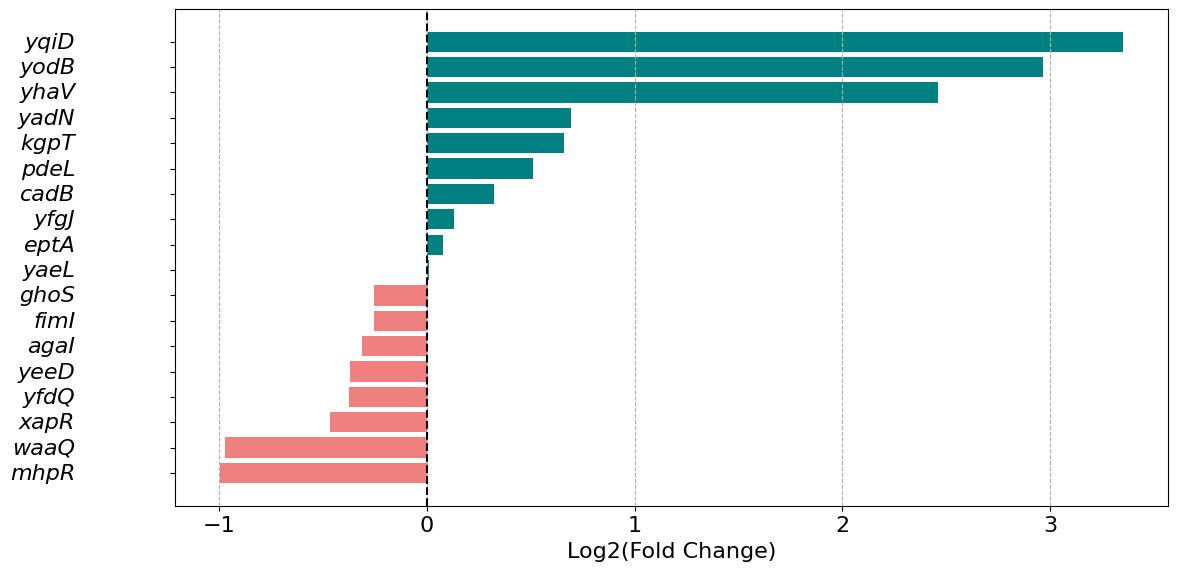

In [11]:
enrichment_results = {}

grouped_columns = {}
group_pairs = []

for column in df.columns:
    prefix = column.split('-')[0]
    if prefix not in grouped_columns:
        grouped_columns[prefix] = []
    grouped_columns[prefix].append(column)

for prefix, columns in grouped_columns.items():
    if len(columns) == 2:
        group_pairs.append((columns[0], columns[1]))


for group1, group2 in group_pairs:
    group1_values = df[group1].dropna()
    group2_values = df[group2].dropna()
    
    # Compute fold enrichment (mean of test values / mean of control values)
    fold_enrichment = group2_values.mean() / group1_values.mean()
    
    # Perform paired samples t-test
    t_stat, p_value = stats.ttest_rel(group1_values, group2_values)
    
    # Check if the enrichment is significant (p-value < 0.05)
    significant_enrichment = p_value < 0.05
    
    # Store fold enrichment and significance information
    enrichment_results[group2] = {'fold_enrichment': fold_enrichment, 'p_value': p_value, 'significant_enrichment': significant_enrichment}

# Extract gene names, fold enrichment values, and significance information
genes = list(enrichment_results.keys())
fold_enrichments = [result['fold_enrichment'] for result in enrichment_results.values()]
p_values = [result['p_value'] for result in enrichment_results.values()]
significant_enrichments = [result['significant_enrichment'] for result in enrichment_results.values()]

# Perform multiple testing correction for p-values (e.g., Benjamini-Hochberg procedure)
reject, p_adjusted, _, _ = multitest.multipletests(p_values, method='fdr_bh')

# Create a DataFrame to summarize the results
results_df = pd.DataFrame({
    'Gene': genes,
    'Fold_Enrichment': fold_enrichments,
    'P_Value': p_values,
    'Adjusted_P_Value': p_adjusted,
    'Significant_Enrichment': significant_enrichments
})



# Take log2 transformation of fold enrichment values
results_df['Log2_Fold_Enrichment'] = np.log2(results_df['Fold_Enrichment'])

# Sort the DataFrame by Log2_Fold_Enrichment
results_df = results_df.sort_values('Log2_Fold_Enrichment')

# Separate upregulated and downregulated genes
downregulated = results_df[results_df['Log2_Fold_Enrichment'] < 0]
upregulated = results_df[results_df['Log2_Fold_Enrichment'] >= 0]

# Combine sorted DataFrames
results_df_sorted = pd.concat([downregulated, upregulated])

# Define colors based on fold enrichment values
bar_colors = ['lightcoral' if fe < 0 else 'teal' for fe in results_df_sorted['Log2_Fold_Enrichment']]

# Create horizontal bar plot
plt.figure(figsize=(12, 6))
plt.rcParams.update({'font.size': 16})
bar_positions = np.arange(len(results_df_sorted))
plt.barh(bar_positions, results_df_sorted['Log2_Fold_Enrichment'], color=bar_colors)

# Italicize y-axis labels
gene_names = results_df_sorted['Gene'].apply(lambda x: x.split('-')[0])
plt.yticks(bar_positions, [])  # Remove default labels
for i, gene in enumerate(gene_names):
    plt.text(-0.1, i, gene, ha='right', va='center', fontsize=16, fontstyle='italic', transform=plt.gca().get_yaxis_transform())

plt.xlabel('Log2(Fold Change)')
plt.grid(axis='x', linestyle='--')
plt.tight_layout()

# Add a vertical line at x=0 to separate up and down regulation
plt.axvline(x=0, color='black', linestyle='--')

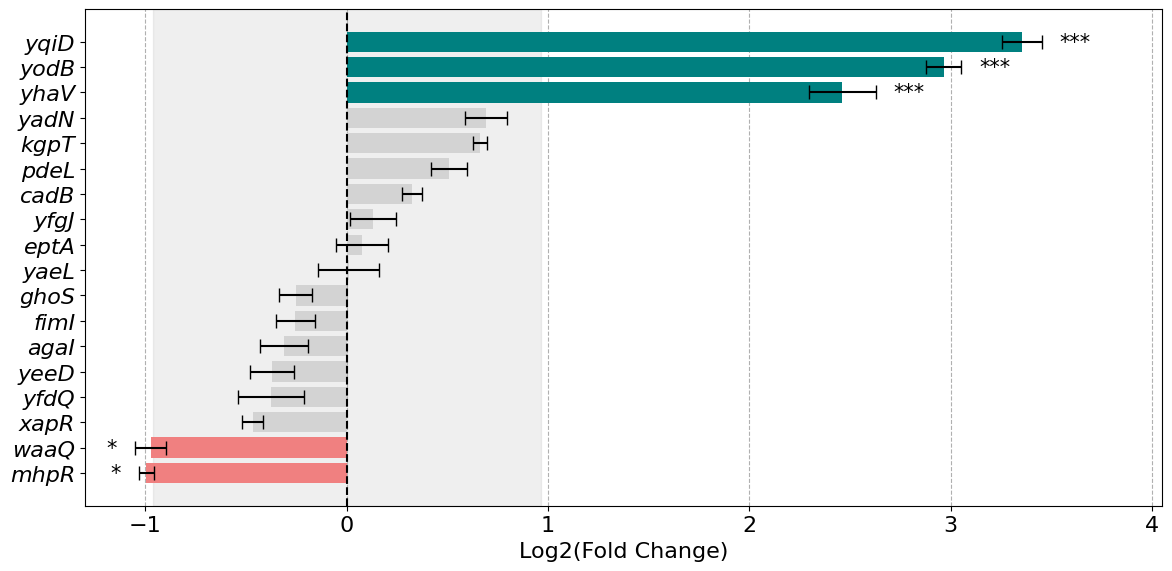

Gene  Log2_Fold_Enrichment  robust_z  effect_size  Adjusted_P_Value
mhpR                    -1      -2.1          8.9           8.7e-28
waaQ                 -0.97        -2          3.6           2.3e-16
xapR                 -0.47     -0.97          2.7           1.6e-16
yfdQ                 -0.38     -0.78         0.74           3.6e-05
yeeD                 -0.37     -0.77            1           3.1e-09
agaI                 -0.31     -0.65         0.78             5e-06
fimI                 -0.26     -0.53          0.8           0.00089
ghoS                 -0.25     -0.52         0.94           6.7e-06
yaeL                0.0089     0.018        0.018              0.78
eptA                 0.076      0.16         0.18              0.21
yfgJ                  0.13      0.27         0.35           7.9e-06
cadB                  0.32      0.67            2           0.00016
pdeL                  0.51       1.1          1.7           2.3e-14
kgpT                  0.66       1.4          5.

In [12]:
results_df_sorted = fig6_res.sort_values('Log2_Fold_Enrichment')
errors_sorted = results_df_sorted['Log2_Error']

bar_colors = ['lightgrey' if abs(fe) <= noise_cut
              else ('lightcoral' if fe < 0 else 'teal')
              for fe in results_df_sorted['Log2_Fold_Enrichment']]

plt.figure(figsize=(12, 6))
plt.rcParams.update({'font.size': 16})
bar_positions = np.arange(len(results_df_sorted))

plt.axvspan(-noise_cut, noise_cut, color='grey', alpha=0.12, zorder=0,
            label=f'within assay noise (±{noise_cut:.2f})')

plt.barh(bar_positions,
         results_df_sorted['Log2_Fold_Enrichment'],
         color=bar_colors,
         xerr=errors_sorted,
         capsize=5,
         zorder=2)

# Italicize y-axis labels
plt.yticks(bar_positions, results_df_sorted['Gene'], fontsize=16, fontstyle='italic')

# Asterisks: how far the change exceeds the negative-control noise
for y, (fe, err) in enumerate(zip(results_df_sorted['Log2_Fold_Enrichment'],
                                  errors_sorted)):
    label = noise_stars(fe)
    if label:
        tip = fe + err if fe >= 0 else fe - err
        plt.text(tip + (0.09 if fe >= 0 else -0.09), y, label, va='center',
                 ha='left' if fe >= 0 else 'right', fontsize=15)

# Add labels and grid
plt.xlabel('Log2(Fold Change)')
plt.grid(axis='x', linestyle='--')
plt.xlim(-1.3, 4.05)
# plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()

# Add a vertical line at x=0 to separate up and down regulation
plt.axvline(x=0, color='black', linestyle='--')

plt.savefig('figure_6a.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('figure_6a.svg',
            dpi=300, bbox_inches='tight',
            transparent=True)

# Display the plot
plt.show()

print(results_df_sorted[['Gene', 'Log2_Fold_Enrichment', 'robust_z',
                         'effect_size', 'Adjusted_P_Value']].to_string(
    index=False, float_format=lambda v: f'{v:.2g}'))

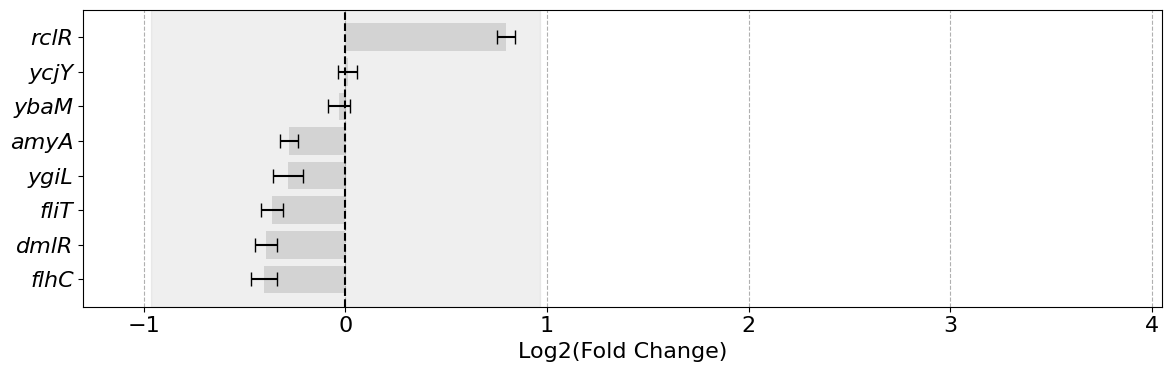

Gene  Fold_Enrichment  Log2_Fold_Enrichment  robust_z  effect_size  Adjusted_P_Value
flhC           0.7553               -0.4049   -0.8397        1.999         4.397e-05
dmlR           0.7609               -0.3942   -0.8176        2.621         4.107e-07
fliT           0.7759                -0.366   -0.7591        2.148         3.518e-05
ygiL           0.8211               -0.2844   -0.5899        1.235           0.00825
amyA            0.824               -0.2793   -0.5791         2.17          4.62e-06
ybaM           0.9784              -0.03157  -0.06548       0.1889            0.3886
ycjY            1.008                0.0113   0.02344       0.0784            0.2203
rclR            1.735                0.7948     1.648        7.486         3.985e-11


In [13]:
nc_sorted = nc_res.sort_values('Log2_Fold_Enrichment')
nc_errors = nc_sorted['Log2_Error']

nc_colors = ['lightgrey' if abs(fe) <= noise_cut
             else ('lightcoral' if fe < 0 else 'teal')
             for fe in nc_sorted['Log2_Fold_Enrichment']]

plt.figure(figsize=(12, 4))
plt.rcParams.update({'font.size': 16})
nc_positions = np.arange(len(nc_sorted))

plt.axvspan(-noise_cut, noise_cut, color='grey', alpha=0.12, zorder=0,
            label=f'within assay noise (±{noise_cut:.2f})')

plt.barh(nc_positions,
         nc_sorted['Log2_Fold_Enrichment'],
         color=nc_colors,
         xerr=nc_errors,
         capsize=5,
         zorder=2)

plt.yticks(nc_positions, nc_sorted['Gene'], fontsize=16, fontstyle='italic')

for y, (fe, err) in enumerate(zip(nc_sorted['Log2_Fold_Enrichment'], nc_errors)):
    label = noise_stars(fe)
    if label:
        tip = fe + err if fe >= 0 else fe - err
        plt.text(tip + (0.09 if fe >= 0 else -0.09), y, label, va='center',
                 ha='left' if fe >= 0 else 'right', fontsize=15)

plt.xlabel('Log2(Fold Change)')
plt.grid(axis='x', linestyle='--')
# plt.legend(loc='lower right', fontsize=11)

plt.xlim(-1.3, 4.05)
plt.tight_layout()
plt.axvline(x=0, color='black', linestyle='--')

plt.savefig('sup_figure_6a.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('sup_figure_6a.svg',
            dpi=300, bbox_inches='tight',
            transparent=True)

plt.show()

print(nc_sorted[['Gene', 'Fold_Enrichment', 'Log2_Fold_Enrichment', 'robust_z',
                 'effect_size', 'Adjusted_P_Value']].to_string(
    index=False, float_format=lambda v: f'{v:.4g}'))

In [14]:
# Same tables but with the empty vector kept (the published chain drops pOT2).
# Each gene carries the pOT2 measured on its own batch, as '<gene>-vector'.
fig6_vec = pd.read_csv('../data/20240620/normalised_gfp_all_clones_with_vector.tsv',
                       sep = '\t', index_col = 0)
fig6_vec = fig6_vec[fig6_vec.index >= 400]

nc_vec = pd.read_csv('../data/20260731/normalised_gfp_notarget_with_vector.tsv',
                     sep = '\t', index_col = 0)
nc_vec = nc_vec[nc_vec.index >= 400]

print(fig6_vec.shape, nc_vec.shape)


(20, 54) (19, 24)


In [15]:
def vs_vector(frame, suffix):
    """Fold enrichment of one construct type against the empty vector pOT2."""
    rows = []
    for gene in sorted(set([c.split('-')[0] for c in frame.columns])):
        pair = frame[[f'{gene}-vector', f'{gene}-{suffix}']].dropna()
        vec, con = pair[f'{gene}-vector'], pair[f'{gene}-{suffix}']

        fe = con.mean() / vec.mean()

        sem_vec = vec.std() / np.sqrt(len(vec))
        sem_con = con.std() / np.sqrt(len(con))
        error = fe * np.sqrt((sem_vec / vec.mean())**2 + (sem_con / con.mean())**2)

        rows.append({'Gene': gene, 'Fold_Enrichment': fe, 'Error': error})

    out = pd.DataFrame(rows)
    out['Log2_Fold_Enrichment'] = np.log2(out['Fold_Enrichment'])
    out['Log2_Error'] = (np.log2(out['Fold_Enrichment'] + out['Error'])
                         - np.log2(out['Fold_Enrichment']))
    return out.set_index('Gene')


def plot_vs_vector(test_res, ctrl_res, order, figsize, fname, xlim = (-1.15, 7.1)):
    """Supplementary Figure 6, with the wild-type construct alongside the variant.

    Bars are means over the analysis window with propagated SEM; no significance
    test is applied.
    """
    order = list(order)
    pos = np.arange(len(order))
    h = 0.38

    plt.figure(figsize = figsize)
    plt.rcParams.update({'font.size': 16})

    for res, offset, colour, label in ((ctrl_res, -h / 2, '#bdbdbd', 'wild-type'),
                                       (test_res, h / 2, 'teal', 'variant')):
        sub = res.loc[order]
        plt.barh(pos + offset, sub['Log2_Fold_Enrichment'], height = h,
                 color = colour, xerr = sub['Log2_Error'], capsize = 3,
                 label = label, zorder = 2)

    plt.yticks(pos, order, fontsize = 16, fontstyle = 'italic')
    plt.ylim(-0.6, len(order) - 0.4)
    plt.xlabel('Log2(Fold Change) vs pOT2')
    plt.ylabel('Gene')
    plt.grid(axis = 'x', linestyle = '--')
    plt.axvline(x = 0, color = 'black', linestyle = '--')
    plt.legend(loc = 'lower right', fontsize = 12)
    if xlim:
        plt.xlim(*xlim)
    plt.tight_layout()

    plt.savefig(f'{fname}.png',
                dpi=300,
                bbox_inches='tight',
                transparent=True
               )
    plt.savefig(f'{fname}.svg',
                dpi=300, bbox_inches='tight',
                transparent=True)

    plt.show()


fig6_test_vec = vs_vector(fig6_vec, 'test')
fig6_ctrl_vec = vs_vector(fig6_vec, 'ctrl')
nc_test_vec = vs_vector(nc_vec, 'test')
nc_ctrl_vec = vs_vector(nc_vec, 'ctrl')


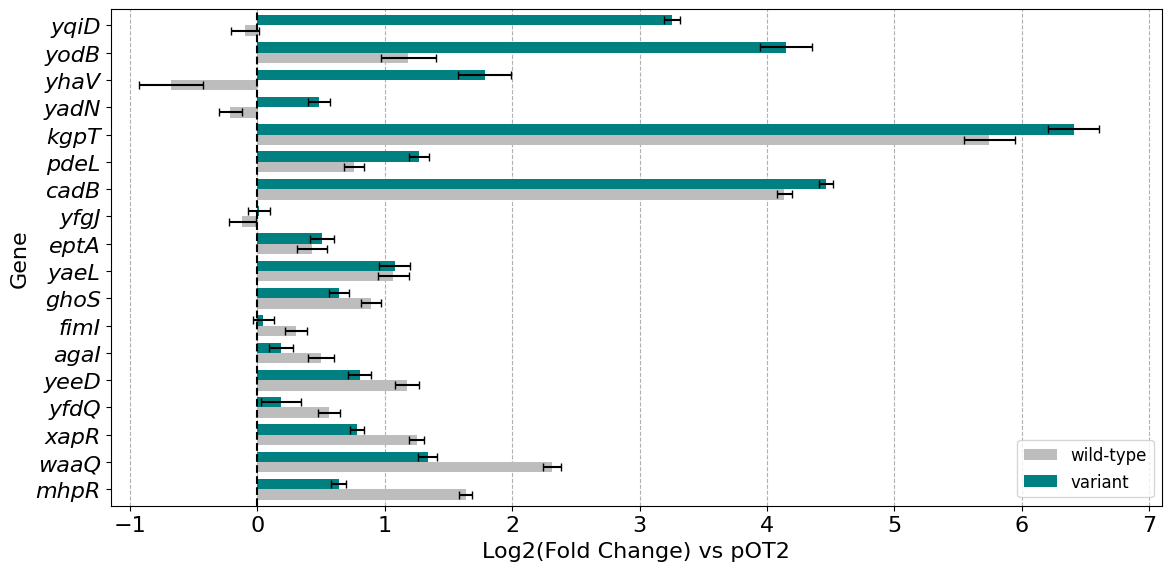

      variant  wild_type
Gene                    
yqiD      3.3     -0.096
yodB      4.2        1.2
yhaV      1.8      -0.68
yadN     0.48      -0.21
kgpT      6.4        5.7
pdeL      1.3       0.76
cadB      4.5        4.1
yfgJ    0.014      -0.12
eptA     0.51       0.43
yaeL      1.1        1.1
ghoS     0.64       0.89
fimI    0.048        0.3
agaI     0.19        0.5
yeeD      0.8        1.2
yfdQ     0.19       0.56
xapR     0.78        1.3
waaQ      1.3        2.3
mhpR     0.64        1.6


In [16]:
plot_vs_vector(fig6_test_vec, fig6_ctrl_vec, results_df_sorted['Gene'],
               (12, 6), 'sup_figure_6_vs_vector')

print(pd.DataFrame({
    'variant': fig6_test_vec['Log2_Fold_Enrichment'],
    'wild_type': fig6_ctrl_vec['Log2_Fold_Enrichment'],
}).loc[list(results_df_sorted['Gene'])[::-1]].to_string(
    float_format=lambda v: f'{v:.2g}'))


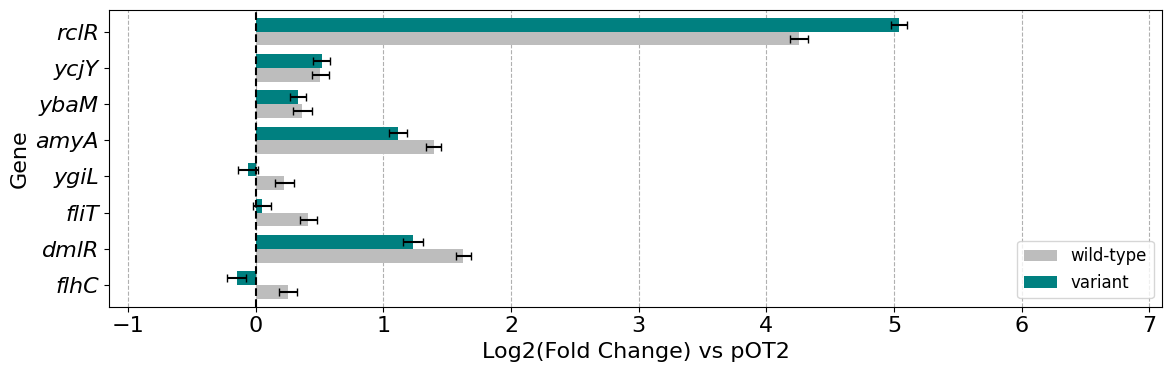

      variant  wild_type
Gene                    
rclR        5        4.3
ycjY     0.52       0.51
ybaM     0.33       0.36
amyA      1.1        1.4
ygiL   -0.061       0.22
fliT    0.047       0.41
dmlR      1.2        1.6
flhC    -0.15       0.26


In [17]:
plot_vs_vector(nc_test_vec, nc_ctrl_vec, nc_sorted['Gene'],
               (12, 4), 'sup_figure_6_vs_vector_negative_controls')

print(pd.DataFrame({
    'variant': nc_test_vec['Log2_Fold_Enrichment'],
    'wild_type': nc_ctrl_vec['Log2_Fold_Enrichment'],
}).loc[list(nc_sorted['Gene'])[::-1]].to_string(
    float_format=lambda v: f'{v:.2g}'))
